In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset_Day8.csv")

print(df.head())
print(df.info())

# checking for missing values
print(df.isnull().sum())
#  checking the statistics
print(df.describe())

zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
for col in zero_cols:
    print(f"{col} has {(df[col] == 0).sum()} zero values")

for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
print(df.isnull().sum())

   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6      148             72  33.6                     0.627   50   
1            1       85             66  26.6                     0.351   31   
2            8      183             64  23.3                     0.672   32   
3            1       89             66  28.1                     0.167   21   
4            0      137             40  43.1                     2.288   33   

   Outcome  
0        1  
1        0  
2        1  
3        0  
4        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   Diabetes

In [ ]:
original_len = len(df)
outlier_idx = set()

for col in df.columns:
    if col == 'Outcome':
        continue
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    print(f"{col}: {mask.sum()} outliers")
    outlier_idx.update(df[mask].index.tolist())

pct = len(outlier_idx) / original_len * 100
print(f"\nTotal outlier rows: {len(outlier_idx)} which is {pct:.1f}% of data")

# since 7.9% is well below 30%, safe to remove all outlier rows
df = df.drop(index=outlier_idx).reset_index(drop=True)
print(f"Rows remaining: {len(df)}")

Pregnancies: 4 outliers
Glucose: 0 outliers
BloodPressure: 14 outliers
BMI: 8 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers

Total outlier rows: 61 which is 7.9% of data
Rows remaining: 707


In [ ]:
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# splitting 70/30 as given in the problem
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=203)

# standard starting point for k is square root of test size
k_default = int(math.sqrt(len(X_test)))
print(f"Default k = sqrt({len(X_test)}) = {k_default}")

knn = KNeighborsClassifier(n_neighbors=k_default, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

Default k = sqrt(213) = 14
Accuracy  : 0.7230046948356808
Precision : 0.5964912280701754
Recall    : 0.4857142857142857
F1 Score  : 0.5354330708661418


Best k for highest F1: 3
Best F1 Score        : 0.6043


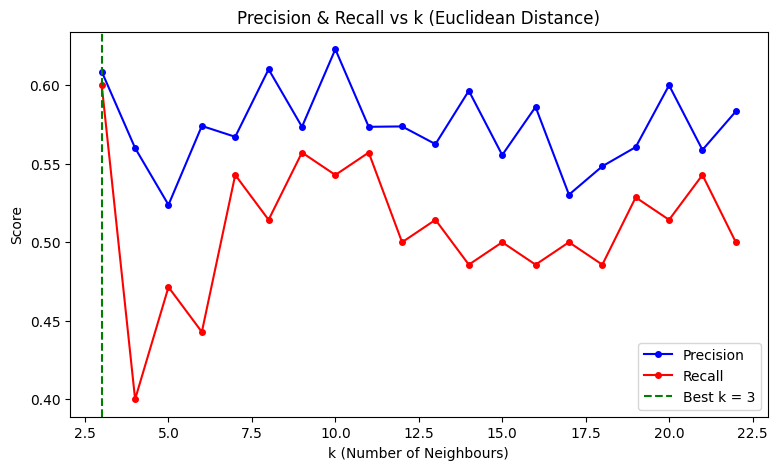

In [5]:
import matplotlib.pyplot as plt

k_values   = range(3, int(math.sqrt(len(X_train))) + 1)
prec_list  = []
rec_list   = []
f1_list    = []

# trying every k from 3 to sqrt(train size) and recording metrics
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    prec_list.append(precision_score(y_test, y_pred_k))
    rec_list.append(recall_score(y_test, y_pred_k))
    f1_list.append(f1_score(y_test, y_pred_k))

# finding the k where F1 score is the highest
best_k  = list(k_values)[np.argmax(f1_list)]
best_f1 = max(f1_list)
print(f"Best k for highest F1: {best_k}")
print(f"Best F1 Score        : {best_f1:.4f}")

# plotting both Precision and Recall on the same graph
plt.figure(figsize=(9, 5))
plt.plot(list(k_values), prec_list, 'b-o', markersize=4, label='Precision')
plt.plot(list(k_values), rec_list,  'r-o', markersize=4, label='Recall')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel("k (Number of Neighbours)")
plt.ylabel("Score")
plt.title("Precision & Recall vs k (Euclidean Distance)")
plt.legend()
plt.show()

In [6]:
# trying 4 different distance metrics across all k values
# to find which combination gives the best F1 score

metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
perf_rows    = []

for dm in metrics_list:
    for k in range(3, int(math.sqrt(len(X_train))) + 1):
        knn_c = KNeighborsClassifier(n_neighbors=k, metric=dm)
        knn_c.fit(X_train, y_train)
        y_pred_c = knn_c.predict(X_test)
        perf_rows.append({
            'k'        : k,
            'Metric'   : dm,
            'Precision': precision_score(y_test, y_pred_c),
            'Recall'   : recall_score(y_test, y_pred_c),
            'F1'       : f1_score(y_test, y_pred_c)
        })

perf_df  = pd.DataFrame(perf_rows)
best_row = perf_df.loc[perf_df['F1'].idxmax()]

print("Best k and Distance Metric combination:")
print(best_row)

print("\nTop 5 combinations by F1 Score:")
print(perf_df.nlargest(5, 'F1').to_string(index=False))

Best k and Distance Metric combination:
k                    3
Metric       euclidean
Precision     0.608696
Recall             0.6
F1            0.604317
Name: 0, dtype: object

Top 5 combinations by F1 Score:
 k    Metric  Precision   Recall       F1
 3 euclidean   0.608696 0.600000 0.604317
 3 minkowski   0.608696 0.600000 0.604317
10 euclidean   0.622951 0.542857 0.580153
10 minkowski   0.622951 0.542857 0.580153
 9 manhattan   0.600000 0.557143 0.577778
